In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from plot import make_theme, interp

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
data1_ZFC = np.loadtxt('../others/MnFe_ZFC.dat')
data1_FC  = np.loadtxt('../others/MnFe_FC.dat')
data2_ZFC = np.loadtxt('../others/MnFeNi_ZFC.dat')
data2_FC  = np.loadtxt('../others/MnFeNi_FC.dat')
data3_ZFC = np.loadtxt('../others/MnFeCoNi_ZFC.dat')
data3_FC  = np.loadtxt('../others/MnFeCoNi_FC.dat')

# Main text figure

Text(0, 0.5, '$\\chi$ ($\\times 10^{-3}$ emu $\\cdot$ Oe$^{-1}$ $\\cdot$ mol$^{-1}$)')

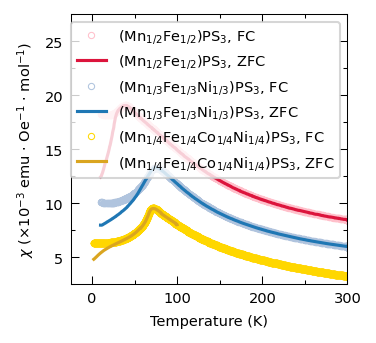

In [3]:
fig, ax = plt.subplots(figsize=(6.75/3,6.75/3), dpi=150, gridspec_kw=dict(left=0.13, right=0.95, bottom=0.15, top=0.95))

yshift = 2

ax.plot(data1_FC[:,0],  data1_FC[:,1]*1e3+yshift*2,  'o', color='pink', ms=3, mfc='none', mew=0.5, label='(Mn$_{1/2}$Fe$_{1/2}$)PS$_3$, FC')
ax.plot(data1_ZFC[:,0], data1_ZFC[:,1]*1e3+yshift*2, '-', color='crimson', lw=1.5, label='(Mn$_{1/2}$Fe$_{1/2}$)PS$_3$, ZFC')
ax.arrow(30, 2.08, 0, -0.1, head_width=5, head_length=0.05, color='k', lw=0.5)
ax.arrow(39, 2.10, 0, -0.1, head_width=5, head_length=0.05, color='k', lw=0.5)

ax.plot(data2_FC[:,0],  data2_FC[:,1]*1e3+yshift,  'o', color='lightsteelblue', ms=3, mfc='none', mew=0.5, label='(Mn$_{1/3}$Fe$_{1/3}$Ni$_{1/3}$)PS$_3$, FC')
ax.plot(data2_ZFC[:,0], data2_ZFC[:,1]*1e3+yshift, '-', color='C0', lw=1.5, label='(Mn$_{1/3}$Fe$_{1/3}$Ni$_{1/3}$)PS$_3$, ZFC')
ax.arrow(60, 1.44, 0, -0.1, head_width=5, head_length=0.05, color='k', lw=0.5)
ax.arrow(75, 1.52, 0, -0.1, head_width=5, head_length=0.05, color='k', lw=0.5)

ax.plot(data3_FC[:,0],  data3_FC[:,1]*1e3,  'o', color='gold', ms=3, mfc='none', mew=0.5, label='(Mn$_{1/4}$Fe$_{1/4}$Co$_{1/4}$Ni$_{1/4}$)PS$_3$, FC')
ax.plot(data3_ZFC[:,0], data3_ZFC[:,1]*1e3, '-', color='goldenrod', lw=1.5, label='(Mn$_{1/4}$Fe$_{1/4}$Co$_{1/4}$Ni$_{1/4}$)PS$_3$, ZFC')
ax.arrow(40, 0.87, 0, -0.1, head_width=5, head_length=0.05, color='k', lw=0.5)
ax.arrow(72, 1.15, 0, -0.1, head_width=5, head_length=0.05, color='k', lw=0.5)

ax.legend()
make_theme(ax, ticklength=4)
ax.set_xlim(-25,300)
ax.set_ylim(2.5,27.5)
ax.set_yticks(np.arange(5,27.5,5))
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$\\chi$ ($\\times 10^{-3}$ emu $\\cdot$ Oe$^{-1}$ $\\cdot$ mol$^{-1}$)')

# fig.savefig('VSM.pdf')

# Measurements of multiple samples

In [4]:
data2_ZFC = np.loadtxt('../others/MnFeCoNi_S2_ZFC.dat')
data2_FC  = np.loadtxt('../others/MnFeCoNi_S2_FC.dat')
data3_ZFC = np.loadtxt('../others/MnFeCoNi_S3_ZFC.dat')
data3_FC  = np.loadtxt('../others/MnFeCoNi_S3_FC.dat')
data4_ZFC = np.loadtxt('../others/MnFeCoNi_S4_ZFC.dat')
data4_FC  = np.loadtxt('../others/MnFeCoNi_S4_FC.dat')

Text(0, 0.5, '$M$ (emu $\\cdot$ mol$^{-1}$)')

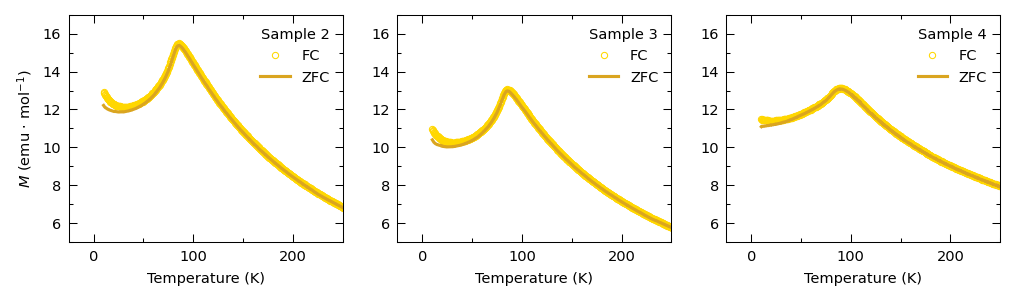

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(6.75,6.75*0.3), dpi=150, gridspec_kw=dict(left=0.06, right=0.98, bottom=0.2, top=0.95, wspace=0.2))

ax = axs[0]
ZFC = data2_ZFC
FC = data2_FC
ax.plot(FC[1:,0],  FC[1:,1],  'o', color='gold', ms=3, mfc='none', mew=0.5, label='FC')
ax.plot(ZFC[1:,0], ZFC[1:,1], '-', color='goldenrod', lw=1.5, label='ZFC')
ax.legend(title='Sample 2', frameon=False)

ax = axs[1]
ZFC = data3_ZFC
FC = data3_FC
ax.plot(FC[1:,0],  FC[1:,1],  'o', color='gold', ms=3, mfc='none', mew=0.5, label='FC')
ax.plot(ZFC[1:,0], ZFC[1:,1], '-', color='goldenrod', lw=1.5, label='ZFC')
ax.legend(title='Sample 3', frameon=False)

ax = axs[2]
ZFC = data4_ZFC
FC = data4_FC
ax.plot(FC[1:,0],  FC[1:,1],  'o', color='gold', ms=3, mfc='none', mew=0.5, label='FC')
ax.plot(ZFC[1:,0], ZFC[1:,1], '-', color='goldenrod', lw=1.5, label='ZFC')
ax.legend(title='Sample 4', frameon=False)

for ax in axs:
    make_theme(ax, ticklength=4)
    ax.set_xlim(-25,250)
    ax.set_xticks(np.arange(0.,250.,100))
    ax.set_ylim(5,17.)
    ax.set_yticks(np.arange(6,16.1,2))
    ax.set_xlabel('Temperature (K)')
axs[0].set_ylabel('$M$ (emu $\\cdot$ mol$^{-1}$)')

# fig.savefig('VSM2.pdf')

# Curie-Weiss fit

In [6]:
def CW(x, C=1., theta=0., chi0=0.):
    return C / (x - theta) + chi0

In [7]:
data3_FC  = np.loadtxt('../others/MnFeCoNi_FC.dat')
x = data3_FC[:,0]
y = data3_FC[:,1] * 1e3

model = lmfit.Model(CW)
params = model.make_params()
params['C'].set(value=1.)
params['theta'].set(value=-40., min=-100., max=0.)
params['chi0'].set(value=1., min=0., max=5.)
choose = x>=80.
result = model.fit(y[choose], x=x[choose], params=params)
print(result.message)
x_fit = np.arange(0.,300.1,1.)
y_fit = model.eval(params=result.params, x=x_fit)

print('Curie constant: {:.3f}'.format(result.params['C'].value/1e3))
mu_eff = np.sqrt(8.*result.params['C'].value/1e3)
print('Effective moment: {:.2f}'.format(mu_eff))
M_calc = np.sqrt(mu_eff**2+1.)-1.
print('Corresponding static moment: {:.2f}'.format(M_calc))

Fit succeeded.
Curie constant: 1.147
Effective moment: 3.03
Corresponding static moment: 2.19


Text(0, 0.5, '$\\chi$ ($\\times 10^{-3}$ emu $\\cdot$ Oe$^{-1}$ $\\cdot$ mol$^{-1}$)')

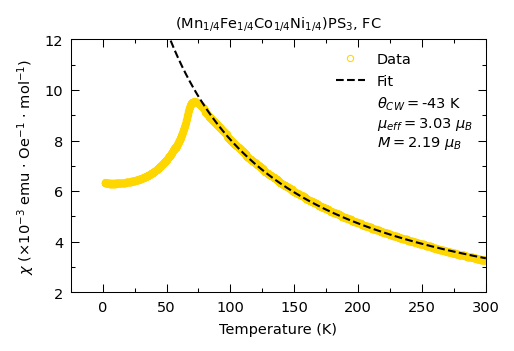

In [8]:
fig, ax = plt.subplots(figsize=(6.75/2,6.75/3), dpi=150, gridspec_kw=dict(left=0.13, right=0.95, bottom=0.15, top=0.9))

ax.plot(x,  y,  'o', color='gold', ms=3, mfc='none', mew=0.5, label='Data')
ax.plot(x_fit, y_fit, lw=1, ls='--', color='k', label='Fit')
label = '$\\theta_{CW}=$' + '{:.0f} K'.format(result.params['theta'].value)
label += '\n$\mu_{eff}=$' + '{:.2f}'.format(mu_eff) + ' $\mu_{B}$'
label += '\n$M=${:.2f}'.format(M_calc) + ' $\mu_{B}$'
ax.plot(np.nan, np.nan, lw=0, label=label)

ax.legend(loc='upper right', frameon=False)
make_theme(ax, ticklength=4)
ax.set_xlim(-25,300)
ax.set_ylim(2,12)
# ax.set_yticks(np.arange(0.,400.1,100.))
ax.set_xlabel('Temperature (K)')
ax.set_title('(Mn$_{1/4}$Fe$_{1/4}$Co$_{1/4}$Ni$_{1/4}$)PS$_3$, FC', fontsize=7)
ax.set_ylabel('$\\chi$ ($\\times 10^{-3}$ emu $\\cdot$ Oe$^{-1}$ $\\cdot$ mol$^{-1}$)')

# fig.savefig('CW.pdf')